# Free-field STOCHASTIC exact-current $K$ validation vs deterministic ground truth

Validates the **stochastic** exact conserved-current correlator (`jj_corr_block_t`, free mode $U=1$,
`corr_nt0<N>_nhits<H>`) against (a) the analytic CFT predictions and (b) the **deterministic** ground
truth `corr_deter_exactsum_L1` -- the *same* Eq.(4.29)/(4.32)/(4.36) observable
(see `stoch_jj_switch_handoff_claude.md`, Sec.1).  Both fold $1/(4\pi)$ into the connected `Vpp`.

**Caveat A (v2-13):** the link/site point-split current gives $G_s/G_t\to-1$ **raw** -- do **NOT** divide
by $(D-1)$.  The $/(D-1)$ in `comp_trio` was a *loc-only* adaptation (loc sums both spatial Pauli
channels); stochastic $K$ is a single per-direction link current, so the ratio is $-1$ directly.

Stochastic errors = **jackknife over hits** (free field: one gauge config; resample hits).
The stored `Vpp[dt]` is **separation-indexed** (full $dt$-loop, per $(hit,t_0)$); we average over hits and
the $t_0$ origins.  Ylm key ordering differs: stochastic `ylm/Vpp/l<l>`, deterministic `ylm/l<l>/Vpp`.

CFT targets: $G_t$ Re$<0$, $G_s$ Re$>0$, $G_s/G_t\to-1$; ylm $g_1\to-\tfrac13 C_j e^{-2t}$,
$g_2\to-\tfrac45 C_j e^{-3t}$, $g_0\to0$; rates $(2,3)$; $g_2 e^{3t}/g_1 e^{2t}\to 12/5=2.4$; $g_1/G_t\to1/3$.

In [1]:
import numpy as np
import h5py
import glob
import matplotlib.pyplot as plt

In [2]:
# ----- config -----
dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'
ESN  = dir1 + 'data_free_vmRe0.000000vmIm0.000000/'
at_cft = 0.2
Nt_cft = 128
Delta_cft = 2.0
L = 1
SD = 'corr_nt02_nhits64'                 # stochastic free L=1 dir (per-hit files; resume/top-up)
EX = 'corr_deter_exactsum_L%d' % L       # deterministic ground truth (single file, exact, summed)

def cft_shape(t):
    return np.exp(-Delta_cft*t) * (1.0 - np.exp(-t))**(-2.0*Delta_cft)

# ----- stochastic free loaders: per-hit files, average over t0 origins, jackknife over hits -----
def stoch_files(corrdir):
    fs = sorted(glob.glob(ESN + corrdir + '/corr.0.h*.h5'))   # '.tmp' excluded by the .h5 suffix
    good = []
    for f in fs:
        with h5py.File(f, 'r') as h:
            if 'complete' in h:
                good.append(f)
    return good

def stoch_hits(corrdir, key):       # key e.g. 'tp/Vpp', 'sp/Vpp', 'ylm/Vpp/l1' -> (n_hits, Nt) complex
    out = []
    for f in stoch_files(corrdir):
        with h5py.File(f, 'r') as h:
            bs = [k for k in h['h0'] if k.startswith('t0_')]
            acc = None
            for b in bs:
                kk = 'h0/' + b + '/' + key
                v = h[kk + '/real'][()] + 1j*h[kk + '/imag'][()]
                acc = v if acc is None else acc + v
            out.append(acc/len(bs))
    return np.array(out)

def jk_mean_err(arr):               # arr (n_hits,Nt) -> (mean, err) over hits, real part
    a = arr.real
    H = len(a)
    s = a.sum(0)
    samp = np.array([(s - a[i])/(H - 1) for i in range(H)])
    est = samp.mean(0)
    var = (H - 1)*np.mean((samp - est)**2, 0)
    return est, np.sqrt(var)

def jk_ratio(num, den):             # leave-one-out ratio of hit-sums -> (mean, err) over Nt
    n = num.real
    d = den.real
    H = len(n)
    sn = n.sum(0)
    sd = d.sum(0)
    samp = np.array([(sn - n[i])/(sd - d[i]) for i in range(H)])
    est = samp.mean(0)
    var = (H - 1)*np.mean((samp - est)**2, 0)
    return est, np.sqrt(var)

# ----- deterministic exactsum ground truth (single file, exact) -----
def load_Vpp(corrdir, proj, origin='t0_0', k=0):
    with h5py.File(ESN + corrdir + '/corr.' + str(k) + '.h5', 'r') as f:
        key = 'h0/' + origin + '/' + proj + '/Vpp'
        return f[key + '/real'][()] + 1j*f[key + '/imag'][()]

def ex_tp():   return load_Vpp(EX, 'tp').real
def ex_sp():   return load_Vpp(EX, 'sp').real
def ex_gl(l):  return load_Vpp(EX, 'ylm/l%d' % l).real

print('stochastic complete hits in %s: %d' % (SD, len(stoch_files(SD))))

stochastic complete hits in corr_nt02_nhits64: 64


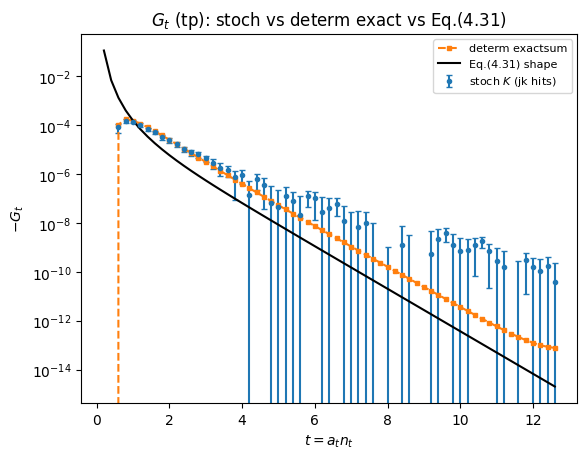

In [3]:
# G_t (tp, Eq.4.31): stochastic (errorbar) vs deterministic exactsum (line) vs CFT shape.  Plot -G_t (Re<0).
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
m, e = jk_mean_err(stoch_hits(SD, 'tp/Vpp'))
plt.errorbar(t, -m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='stoch $K$ (jk hits)')
anchor = -m[ref]
try:
    g = ex_tp(); plt.plot(t, -g[dt], 's--', ms=3, label='determ exactsum'); anchor = -g[ref]
except (OSError, KeyError):
    print('exactsum tp not complete yet (still .tmp); CFT line anchored to stoch')
B = anchor/cft_shape(t[ref-1])
plt.plot(t, B*cft_shape(t), 'k-', label='Eq.(4.31) shape')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$-G_t$')
plt.title(r'$G_t$ (tp): stoch vs determ exact vs Eq.(4.31)'); plt.legend(fontsize=8)
plt.savefig('jj_free_stoch_tp.pdf', bbox_inches='tight')

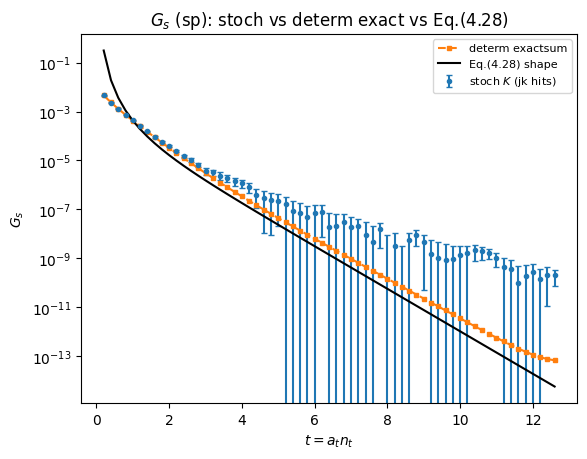

In [4]:
# G_s (sp, Eq.4.28): stochastic (errorbar) vs deterministic exactsum (line) vs CFT shape.  G_s Re>0.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
m, e = jk_mean_err(stoch_hits(SD, 'sp/Vpp'))
plt.errorbar(t, m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='stoch $K$ (jk hits)')
anchor = m[ref]
try:
    g = ex_sp(); plt.plot(t, g[dt], 's--', ms=3, label='determ exactsum'); anchor = g[ref]
except (OSError, KeyError):
    print('exactsum sp not complete yet (still .tmp); CFT line anchored to stoch')
B = anchor/cft_shape(t[ref-1])
plt.plot(t, B*cft_shape(t), 'k-', label='Eq.(4.28) shape')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$G_s$')
plt.title(r'$G_s$ (sp): stoch vs determ exact vs Eq.(4.28)'); plt.legend(fontsize=8)
plt.savefig('jj_free_stoch_sp.pdf', bbox_inches='tight')

stoch ratio @dt=5:  -3.0944 +- 0.4066


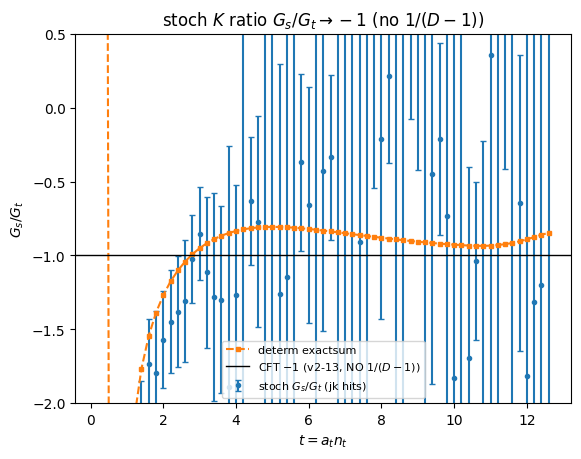

In [5]:
# RATIO G_s/G_t -> -1 (v2-13, Eq.4.28/4.29).  Stochastic K is a single per-direction LINK current:
# NO 1/(D-1) (that was loc-only).  Stoch jackknife errorbar vs deterministic exactsum vs CFT -1.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
m, e = jk_ratio(stoch_hits(SD, 'sp/Vpp'), stoch_hits(SD, 'tp/Vpp'))
plt.errorbar(t, m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label=r'stoch $G_s/G_t$ (jk hits)')
try:
    r = ex_sp()/ex_tp(); plt.plot(t, r[dt], 's--', ms=3, label='determ exactsum')
except (OSError, KeyError):
    print('exactsum ratio not complete yet')
plt.axhline(-1.0, color='k', lw=1, label=r'CFT $-1$ (v2-13, NO $1/(D-1)$)')
plt.ylim(-2.0, 0.5); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$G_s/G_t$')
plt.title(r'stoch $K$ ratio $G_s/G_t \to -1$ (no $1/(D-1)$)'); plt.legend(fontsize=8)
plt.savefig('jj_free_stoch_ratio.pdf', bbox_inches='tight')
print('stoch ratio @dt=%d:  % .4f +- %.4f' % (ref, m[ref], e[ref]))

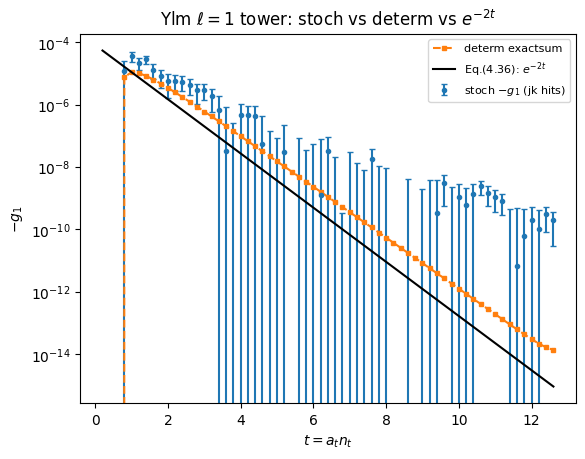

In [6]:
# Ylm ell=1 tower: -g_1 (stoch errorbar + determ exact) vs e^{-2t}.  log; anchored at dt=ref.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
m, e = jk_mean_err(stoch_hits(SD, 'ylm/Vpp/l1'))
plt.errorbar(t, -m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='stoch $-g_1$ (jk hits)')
anchor = -m[ref]
try:
    g = ex_gl(1); plt.plot(t, -g[dt], 's--', ms=3, label='determ exactsum'); anchor = -g[ref]
except (OSError, KeyError):
    pass
A = anchor/np.exp(-2.0*t[ref-1])
plt.plot(t, A*np.exp(-2.0*t), 'k-', label=r'Eq.(4.36): $e^{-2t}$')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$-g_1$')
plt.title(r'Ylm $\ell=1$ tower: stoch vs determ vs $e^{-2t}$'); plt.legend(fontsize=8)
plt.savefig('jj_free_stoch_ylm_l1.pdf', bbox_inches='tight')

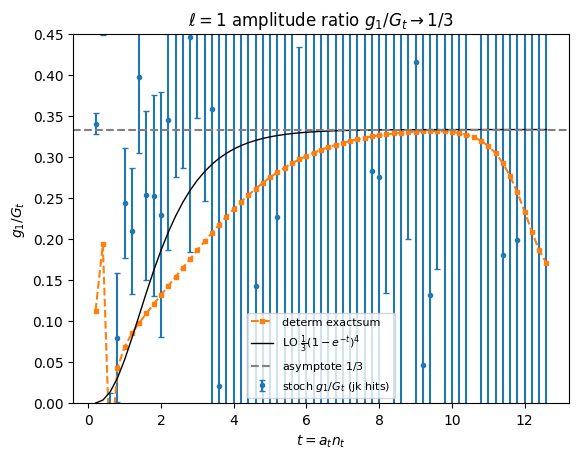

In [7]:
# ell=1 amplitude ratio g_1/G_t -> 1/3 (same source).  CFT: g_1=-1/3 C_j e^{-2t}, G_t=-C_j e^{-2t}(1-e^{-t})^{-4}.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
plt.figure()
m, e = jk_ratio(stoch_hits(SD, 'ylm/Vpp/l1'), stoch_hits(SD, 'tp/Vpp'))
plt.errorbar(t, m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label=r'stoch $g_1/G_t$ (jk hits)')
try:
    r = ex_gl(1)/ex_tp(); plt.plot(t, r[dt], 's--', ms=3, label='determ exactsum')
except (OSError, KeyError):
    pass
plt.plot(t, (1.0/3.0)*(1.0 - np.exp(-t))**4, 'k-', lw=1, label=r'LO $\frac{1}{3}(1-e^{-t})^4$')
plt.axhline(1.0/3.0, color='gray', ls='dashed', label=r'asymptote $1/3$')
plt.ylim(0, 0.45); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$g_1/G_t$')
plt.title(r'$\ell=1$ amplitude ratio $g_1/G_t \to 1/3$'); plt.legend(fontsize=8)
plt.savefig('jj_free_stoch_g1_over_Gt.pdf', bbox_inches='tight')

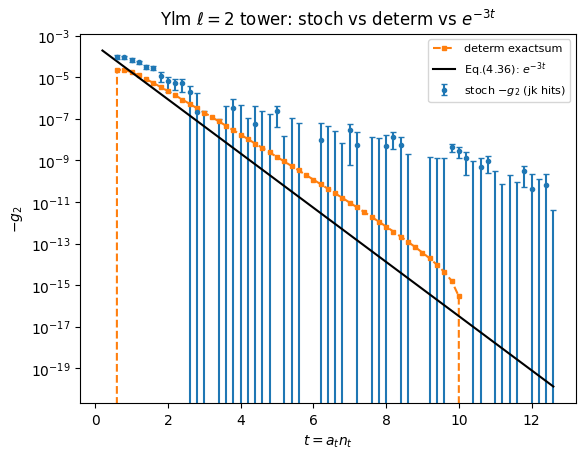

In [8]:
# Ylm ell=2 tower: -g_2 (stoch errorbar + determ exact) vs e^{-3t}.  log; anchored at dt=ref.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
m, e = jk_mean_err(stoch_hits(SD, 'ylm/Vpp/l2'))
plt.errorbar(t, -m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='stoch $-g_2$ (jk hits)')
anchor = -m[ref]
try:
    g = ex_gl(2); plt.plot(t, -g[dt], 's--', ms=3, label='determ exactsum'); anchor = -g[ref]
except (OSError, KeyError):
    pass
A = anchor/np.exp(-3.0*t[ref-1])
plt.plot(t, A*np.exp(-3.0*t), 'k-', label=r'Eq.(4.36): $e^{-3t}$')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$-g_2$')
plt.title(r'Ylm $\ell=2$ tower: stoch vs determ vs $e^{-3t}$'); plt.legend(fontsize=8)
plt.savefig('jj_free_stoch_ylm_l2.pdf', bbox_inches='tight')

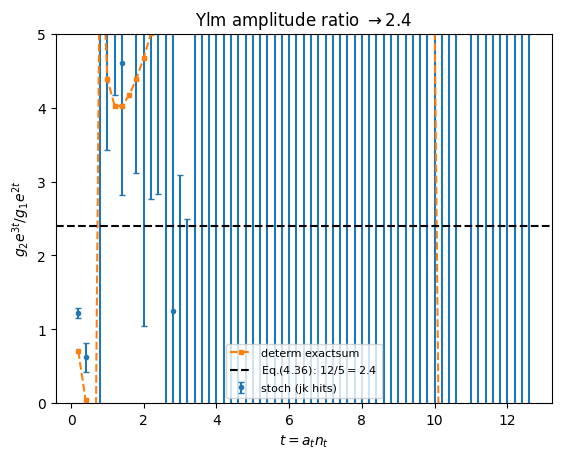

In [9]:
# Ylm amplitude ratio g_2 e^{3t}/g_1 e^{2t} = (g_2/g_1) e^{t} -> 12/5 = 2.4 (Eq.4.36).
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
plt.figure()
m, e = jk_ratio(stoch_hits(SD, 'ylm/Vpp/l2'), stoch_hits(SD, 'ylm/Vpp/l1'))   # g2/g1
fac = np.exp(t)
plt.errorbar(t, m[dt]*fac, yerr=e[dt]*fac, fmt='o', ms=3, capsize=2, label='stoch (jk hits)')
try:
    r = ex_gl(2)/ex_gl(1); plt.plot(t, r[dt]*fac, 's--', ms=3, label='determ exactsum')
except (OSError, KeyError):
    pass
plt.axhline(12.0/5.0, color='k', ls='dashed', label=r'Eq.(4.36): $12/5=2.4$')
plt.ylim(0, 5); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$g_2 e^{3t}/g_1 e^{2t}$')
plt.title(r'Ylm amplitude ratio $\to 2.4$'); plt.legend(fontsize=8)
plt.savefig('jj_free_stoch_ylm_ratio.pdf', bbox_inches='tight')

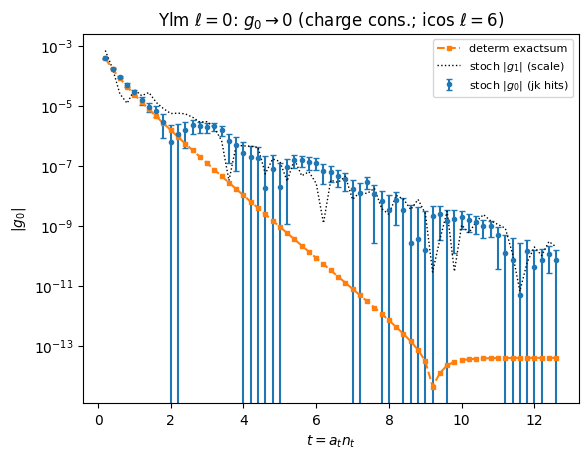

In [10]:
# ell=0 mode: |g_0| -> 0 (charge conservation; icosahedral l=6 aliasing).  stoch vs determ; |g_1| as scale.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
plt.figure()
m, e = jk_mean_err(stoch_hits(SD, 'ylm/Vpp/l0'))
plt.errorbar(t, np.abs(m[dt]), yerr=e[dt], fmt='o', ms=3, capsize=2, label='stoch $|g_0|$ (jk hits)')
try:
    g = ex_gl(0); plt.plot(t, np.abs(g[dt]), 's--', ms=3, label='determ exactsum')
except (OSError, KeyError):
    pass
m1, _ = jk_mean_err(stoch_hits(SD, 'ylm/Vpp/l1'))
plt.plot(t, np.abs(m1[dt]), 'k:', lw=1, label='stoch $|g_1|$ (scale)')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|g_0|$')
plt.title(r'Ylm $\ell=0$: $g_0 \to 0$ (charge cons.; icos $\ell=6$)'); plt.legend(fontsize=8)
plt.savefig('jj_free_stoch_ylm_l0.pdf', bbox_inches='tight')

In [11]:
# SIGN + magnitude table @dt=5 (stoch +- jk err vs determ exactsum).  Expect G_t<0, G_s>0, ratio -> -1.
ref = 5
mt, et = jk_mean_err(stoch_hits(SD, 'tp/Vpp'))
ms, es = jk_mean_err(stoch_hits(SD, 'sp/Vpp'))
mr, er = jk_ratio(stoch_hits(SD, 'sp/Vpp'), stoch_hits(SD, 'tp/Vpp'))
print('STOCH  @dt=%d:  G_t=% .3e +- %.1e   G_s=% .3e +- %.1e   G_s/G_t=% .3f +- %.3f' %
      (ref, mt[ref], et[ref], ms[ref], es[ref], mr[ref], er[ref]))
try:
    print('DETERM @dt=%d:  G_t=% .3e               G_s=% .3e               G_s/G_t=% .3f' %
          (ref, ex_tp()[ref], ex_sp()[ref], (ex_sp()/ex_tp())[ref]))
except (OSError, KeyError):
    print('DETERM exactsum not complete yet (still .tmp)')
print('CFT: G_t<0, G_s>0, G_s/G_t -> -1')

STOCH  @dt=5:  G_t=-1.432e-04 +- 1.9e-05   G_s= 4.430e-04 +- 1.6e-05   G_s/G_t=-3.094 +- 0.407
DETERM @dt=5:  G_t=-1.573e-04               G_s= 4.260e-04               G_s/G_t=-2.709
CFT: G_t<0, G_s>0, G_s/G_t -> -1


In [12]:
# Ylm convention-free checks (print): rates -> (2,3); g_2 e^{3t}/g_1 e^{2t} -> 2.4; g_0/g_1 -> 0.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
def eff_rate(g):
    gg = g[dt]
    return -np.log(gg[1:]/gg[:-1])/at_cft
mg0, _ = jk_mean_err(stoch_hits(SD, 'ylm/Vpp/l0'))
mg1, _ = jk_mean_err(stoch_hits(SD, 'ylm/Vpp/l1'))
mg2, _ = jk_mean_err(stoch_hits(SD, 'ylm/Vpp/l2'))
print('predicted: l1 rate 2.0, l2 rate 3.0, ratio 2.4, g0/g1 -> 0')
r1 = np.mean(eff_rate(mg1)[14:20]); r2 = np.mean(eff_rate(mg2)[14:20])
rat = np.mean(((mg2[dt]*np.exp(3*t))/(mg1[dt]*np.exp(2*t)))[12:20])
print('STOCH : rate(l1)=%.3f  rate(l2)=%.3f  ratio=%.3f  g0/g1[5]=%.5f' %
      (r1, r2, rat, (mg0[dt]/mg1[dt])[5]))
try:
    e0 = ex_gl(0); e1 = ex_gl(1); e2 = ex_gl(2)
    er1 = np.mean(eff_rate(e1)[14:20]); er2 = np.mean(eff_rate(e2)[14:20])
    erat = np.mean(((e2[dt]*np.exp(3*t))/(e1[dt]*np.exp(2*t)))[12:20])
    print('DETERM: rate(l1)=%.3f  rate(l2)=%.3f  ratio=%.3f  g0/g1[5]=%.5f' %
          (er1, er2, erat, (e0[dt]/e1[dt])[5]))
except (OSError, KeyError):
    print('DETERM exactsum not complete yet')

predicted: l1 rate 2.0, l2 rate 3.0, ratio 2.4, g0/g1 -> 0
STOCH : rate(l1)=nan  rate(l2)=nan  ratio=-60.532  g0/g1[5]=-0.71342
DETERM: rate(l1)=1.831  rate(l2)=2.444  ratio=7.681  g0/g1[5]=-1.33484


/tmp/ipykernel_438187/837527809.py:5: RuntimeWarning: invalid value encountered in log
  return -np.log(gg[1:]/gg[:-1])/at_cft
